<a href="https://colab.research.google.com/github/fjnarvaezo1-dotcom/M-TODOS-ESTAD-STICOS-EN-LA-CIENCIA-DE-DATOS-Y-ANAL-TICA---203008072A_2204-/blob/main/M%C3%89TODOS_ESTAD%C3%8DSTICOS_EN_LA_CIENCIA_DE_DATOS_Y_ANAL%C3%8DTICA_(203008072A_2204).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Paso 1. Descarga de Datos**



In [19]:
from google.colab import drive
import pandas as pd
drive.mount("/content/drive", force_remount=True)
ruta_archivo = "/content/drive/MyDrive/Colab Notebooks/Anexo 1 - Base de Datos dynamic_pricing (3).csv"
df = pd.read_csv(ruta_archivo, sep=',')
informacion = pd.DataFrame(df)
informacion.head(10000)


Mounted at /content/drive


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422
...,...,...,...,...,...,...,...,...,...,...
995,33,23,Urban,Gold,24,4.21,Morning,Premium,11,91.389526
996,84,29,Urban,Regular,92,4.55,Morning,Premium,94,424.155987
997,44,6,Suburban,Gold,80,4.13,Night,Premium,40,157.364830
998,53,27,Suburban,Regular,78,3.63,Night,Premium,58,279.095048


## **Paso 2**

### - 2.1 Teorema Central del Límite (TCL) y su aplicación práctica

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

datos = informacion['Expected_Ride_Duration'].dropna()
print(datos)


0       90
1       43
2       76
3      134
4      149
      ... 
995     11
996     94
997     40
998     58
999    147
Name: Expected_Ride_Duration, Length: 1000, dtype: int64


In [26]:
# Parámetros
n = 30 # tamaño de cada muestra
repeticiones = 1000 # número de muestras

In [28]:
# Parámetros
n = 30 # tamaño de cada muestra
repeticiones = 1000 # número de muestras

medias_muestrales = []
for i in range(repeticiones):
  muestra = np.random.choice(datos, size=n, replace=True)
  medias_muestrales.append(np.mean(muestra))

medias_muestrales = np.array(medias_muestrales)

media_medias = np.mean(medias_muestrales)
std_medias = np.std(medias_muestrales)
print(f"Media de las medias muestrales: {media_medias:.2f}")
print(f"Desviación estándar de las medias: {std_medias:.2f}")

Media de las medias muestrales: 99.27
Desviación estándar de las medias: 8.92


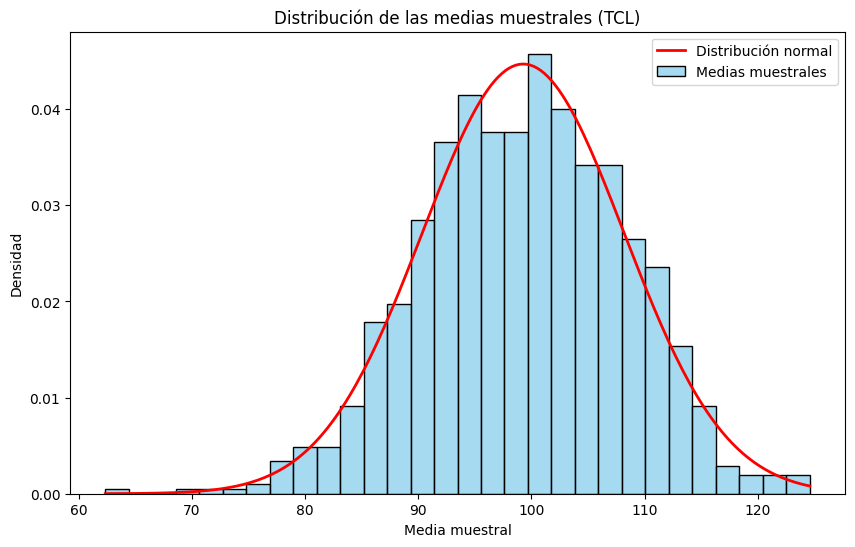

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
plt.figure(figsize=(10,6))

sns.histplot(
    medias_muestrales,
    bins=30,
    stat='density',
    color='skyblue',
    edgecolor='black',
    label='Medias muestrales'
)

x = np.linspace(min(medias_muestrales),
                max(medias_muestrales),
                200)

plt.plot(
    x,
    norm.pdf(x, media_medias, std_medias),
    color='red',
    linewidth=2,
    label='Distribución normal'
)

plt.title('Distribución de las medias muestrales (TCL)')
plt.xlabel('Media muestral')
plt.ylabel('Densidad')
plt.legend()
plt.show()


#### Graficar la distribución de las medias muestrales.

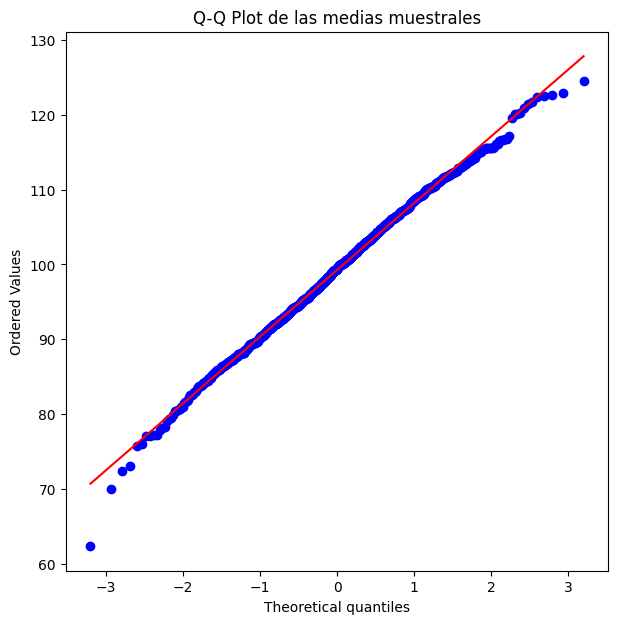

In [29]:
from scipy import stats
plt.figure(figsize=(7,7))
stats.probplot(medias_muestrales, dist="norm", plot=plt)
plt.title("Q-Q Plot de las medias muestrales")
plt.show()

#### Verificar empíricamente la forma aproximadamente normal de la  distribución muestral.

In [31]:
from scipy.stats import shapiro

stat, p = shapiro(medias_muestrales[:500])  # Shapiro funciona mejor con muestras no muy grandes

print("Estadístico:", stat)
print("Valor p:", p)

if p > 0.05:
    print("No se rechaza la hipótesis de normalidad.")
else:
    print("Se rechaza la hipótesis de normalidad.")

Estadístico: 0.9974830926898967
Valor p: 0.6554634895680966
No se rechaza la hipótesis de normalidad.


**Distribución de las medias muestrales**

Se generaron 1000 muestras aleatorias de tamaño 30 a partir de la variable Expected_Ride_Duration. Para cada muestra se calculó su media, obteniendo una distribución de medias muestrales.

**Verificación del Teorema Central del Límite**

El histograma de las medias muestrales presentó una forma aproximadamente campaniforme y simétrica. Además, el gráfico Q-Q mostró que la mayoría de los puntos se alinean con la recta teórica de una distribución normal, lo que evidencia el comportamiento esperado según el Teorema Central del Límite.

**Aplicación práctica del TCL**

El Teorema Central del Límite establece que, para muestras suficientemente grandes (generalmente \[
n \geq 30
\]), la distribución de las medias muestrales tiende a una distribución normal, independientemente de la forma de la distribución original de la población.

Gracias a esta propiedad es posible utilizar técnicas de inferencia estadística, como intervalos de confianza y pruebas de hipótesis, para estimar parámetros poblacionales de la variable Expected_Ride_Duration, aun cuando la distribución original de los datos no sea perfectamente normal.

Si me muestras el nombre de tu DataFrame en Colab (o una captura de las primeras filas con df.head()), puedo adaptarte el código exactamente a tu caso y ayudarte a redactar los resultados con los valores reales obtenidos.

### - 2.2 Intervalos de Confianza (IC)

#### IC del 95% para la media de Expected_Ride_Duration

In [33]:
import numpy as np
from scipy import stats

x = informacion['Expected_Ride_Duration']

n = len(x)
media = x.mean()
desv = x.std(ddof=1)

ic = stats.t.interval(
    confidence=0.95,
    df=n-1,
    loc=media,
    scale=desv/np.sqrt(n)
)

print(f"Media: {media:.2f}")
print(f"IC 95%: ({ic[0]:.2f}, {ic[1]:.2f})")

Media: 99.59
IC 95%: (96.54, 102.64)


**Media**: La duración promedio de los viajes esperados es de 99.59 unidades de tiempo (asumiendo que las unidades son minutos o alguna otra medida de tiempo).

**IC 95%**: El intervalo de confianza del 95% es (96.54, 102.64). Esto significa que podemos estar 95% seguros de que la verdadera media poblacional de la duración esperada de los viajes se encuentra entre 96.54 y 102.64.

#### IC del 95% para la proporción de calificaciones excelentes (≥ 4.0)

In [35]:
from statsmodels.stats.proportion import proportion_confint

excelente = informacion['Average_Ratings'] >= 4.0

n = len(excelente)
x = excelente.sum()

proporcion = x / n

li, ls = proportion_confint(
    count=x,
    nobs=n,
    alpha=0.05,
    method='wilson'
)

print(f"Proporción excelente: {proporcion:.4f}")
print(f"IC 95%: ({li:.4f}, {ls:.4f})")

Proporción excelente: 0.6860
IC 95%: (0.6566, 0.7140)


Es decir, en tu muestra aproximadamente el 68.6% de los usuarios calificaron el servicio con una puntuación igual o superior a 4.0, considerada excelente.

¿Qué significa el IC (0.6566, 0.7140)?

Significa que, con un 95% de confianza, la proporción real de clientes que califican el servicio como excelente está entre:

65.66%
71.40%
Interpretación para el informe

Se encontró que el 68.6% de los usuarios otorgó calificaciones excelentes (≥ 4.0). Además, con un nivel de confianza del 95%, se estima que la proporción real de usuarios satisfechos en la población se encuentra entre 65.66% y 71.40%. Este resultado indica que aproximadamente siete de cada diez usuarios perciben positivamente el servicio, lo que constituye un indicador favorable de calidad y satisfacción del cliente.

Utilidad para la toma de decisiones
Medir la satisfacción general de los usuarios.
Evaluar si el servicio cumple los estándares de calidad.
Definir estrategias para aumentar la fidelización y retención de clientes.
Detectar oportunidades de mejora si se desea superar el 70% o 80% de satisfacción

#### IC del 95% para la varianza de Historical_Cost_of_Ride

In [36]:
from scipy.stats import chi2
import numpy as np

x = informacion['Historical_Cost_of_Ride']

n = len(x)
varianza = np.var(x, ddof=1)

alpha = 0.05

li = ((n-1) * varianza) / chi2.ppf(1 - alpha/2, n-1)
ls = ((n-1) * varianza) / chi2.ppf(alpha/2, n-1)

print(f"Varianza: {varianza:.2f}")
print(f"IC 95%: ({li:.2f}, {ls:.2f})")

Varianza: 35028.40
IC 95%: (32148.63, 38315.27)


**Varianza del costo histórico de los viajes**

¿Qué significa la varianza 35028.40?

La varianza mide la dispersión de los costos respecto a su promedio.

Un valor de 35028.40 indica que los costos de los viajes presentan una variabilidad considerable.

Como la varianza está en unidades cuadradas, es más fácil interpretar la desviación estándar:

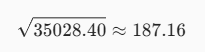

Esto significa que, en promedio, los costos se alejan alrededor de 187 unidades monetarias respecto a su valor medio.

¿Qué significa el IC (32148.63, 38315.27)?

Con un 95% de confianza, la varianza real de los costos de los viajes está entre:

32148.63
38315.27

Lo que confirma que existe una dispersión importante en los precios.

Interpretación para el informe

La varianza muestral del costo histórico de los viajes fue de 35028.40. El intervalo de confianza al 95% indica que la varianza poblacional se encuentra entre 32148.63 y 38315.27. Estos resultados reflejan una variabilidad significativa en los costos de los viajes, lo que sugiere que existen diferencias importantes entre trayectos debido a factores como duración, ubicación, tipo de vehículo y condiciones del servicio.

#### Resumen sencillo

✅ 68.6% de los usuarios califican el servicio como excelente.

✅ La proporción real de usuarios satisfechos probablemente está entre 65.66% y 71.40%.

✅ Los costos de los viajes presentan una dispersión considerable (varianza ≈ 35.028), lo que indica que algunos viajes pueden ser mucho más costosos que otros.

✅ Los intervalos de confianza permiten estimar los verdaderos parámetros de la población y aportan evidencia estadística para la toma de decisiones sobre calidad del servicio y control de costos.

### - 2.3 Pruebas de Hipótesis para Comparación de Grupos


#### - Prueba t de medias

In [37]:
from scipy.stats import ttest_ind

# Filtrar grupos
regular = df[df['Customer_Loyalty_Status']=='Regular']['Expected_Ride_Duration']
gold = df[df['Customer_Loyalty_Status']=='Gold']['Expected_Ride_Duration']

# Prueba t de Welch
t_stat, p_value = ttest_ind(regular, gold, equal_var=False)

print("Media Regular:", regular.mean())
print("Media Gold:", gold.mean())
print("Estadístico t:", t_stat)
print("p-valor:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Se rechaza H0")
else:
    print("No se rechaza H0")

Media Regular: 100.565625
Media Gold: 101.60383386581469
Estadístico t: -0.2624396055725957
p-valor: 0.7930683262978924
No se rechaza H0


#### -  Prueba de diferencia de proporciones

In [38]:
df['Rating_Alto'] = (df['Average_Ratings'] >= 4.0).astype(int)

In [39]:
from statsmodels.stats.proportion import proportions_ztest

economy = df[df['Vehicle_Type'] == 'Economy']
premium = df[df['Vehicle_Type'] == 'Premium']

exitos = [
    economy['Rating_Alto'].sum(),
    premium['Rating_Alto'].sum()
]

muestras = [
    len(economy),
    len(premium)
]

z_stat, p_value = proportions_ztest(exitos, muestras)

print("Proporción Economy:",
      economy['Rating_Alto'].mean())

print("Proporción Premium:",
      premium['Rating_Alto'].mean())

print("Estadístico z:", z_stat)
print("p-valor:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Se rechaza H0")
else:
    print("No se rechaza H0")

Proporción Economy: 0.696652719665272
Proporción Premium: 0.6762452107279694
Estadístico z: 0.6945640698522973
p-valor: 0.4873285358474382
No se rechaza H0


##### Análisis Inferencial de Datos

##### 1. Prueba t para comparar la media de `Expected_Ride_Duration` entre clientes Regular y Gold

###### Hipótesis
*   **Hipótesis nula (H₀):** \(\mu_{\text{Regular}} = \mu_{\text{Gold}}\)  
    La duración esperada promedio del viaje es igual para los clientes con estado de lealtad Regular y Gold.
*   **Hipótesis alternativa (H₁):** \(\mu_{\text{Regular}} \neq \mu_{\text{Gold}}\)  
    La duración esperada promedio del viaje es diferente entre los clientes Regular y Gold.

###### Resultados
*   **Media Regular:** 100.57
*   **Media Gold:** 101.60
*   **Estadístico de prueba (t):** -0.2624
*   **p-valor:** 0.7931
*   **Nivel de significancia (α):** 0.05

###### Decisión
Como el p-valor = 0.7931 > 0.05, **no se rechaza la hipótesis nula (H₀)**.

###### Conclusión
Con un nivel de significancia del 5%, **no existe evidencia estadística suficiente** para afirmar que la duración esperada promedio del viaje (`Expected_Ride_Duration`) sea diferente entre los clientes de categoría Regular y Gold. Aunque la media de los clientes Gold (101.60) es ligeramente superior a la de los clientes Regular (100.57), esta diferencia no es estadísticamente significativa.

---

##### 2. Prueba de diferencia de proporciones para `Average_Ratings` ≥ 4.0 según `Vehicle_Type` (Economy vs Premium)

###### Hipótesis
*   **Hipótesis nula (H₀):**
    La proporción de usuarios con calificaciones iguales o superiores a 4.0 es la misma para los vehículos Economy y Premium.
*   **Hipótesis alternativa (H₁):**
    La proporción de usuarios con calificaciones iguales o superiores a 4.0 es diferente entre los vehículos Economy y Premium.

###### Resultados
*   **Proporción Economy:** 0.6967 (69.67%)
*   **Proporción Premium:** 0.6762 (67.62%)
*   **Estadístico de prueba (z):** 0.6946
*   **p-valor:** 0.4873
*   **Nivel de significancia (α):** 0.05

###### Decisión
Como el p-valor = 0.4873 > 0.05, **no se rechaza la hipótesis nula (H₀)**.

###### Conclusión
Con un nivel de significancia del 5%, **no existe evidencia estadística suficiente** para afirmar que la proporción de usuarios con calificaciones altas (`Average_Ratings` ≥ 4.0) difiera entre los vehículos Economy y Premium. Aunque la proporción observada es ligeramente mayor para los vehículos Economy (69.67%) que para los Premium (67.62%), la diferencia no resulta estadísticamente significativa.

---

##### Conclusión General del Análisis Inferencial

Los resultados de las pruebas estadísticas muestran que:
*   **No existen diferencias significativas** en la duración esperada de los viajes entre clientes Regular y Gold (p = 0.7931).
*   **No existen diferencias significativas** en la proporción de calificaciones altas (≥ 4.0) entre vehículos Economy y Premium (p = 0.4873).

**Por lo tanto**, para este conjunto de datos, el estado de lealtad del cliente y el tipo de vehículo no presentan evidencia estadística suficiente para explicar variaciones en las variables analizadas.

#### - 2.4 Pruebas de Varianza (F de Fisher)

In [42]:
from scipy.stats import f
import numpy as np

# Seleccionar los dos grupos
grupo1 = df[df['Customer_Loyalty_Status'] == 'Loyal']['Expected_Ride_Duration']
grupo2 = df[df['Customer_Loyalty_Status'] == 'Regular']['Expected_Ride_Duration']
print(len(grupo1))
print(len(grupo2))
print(df['Customer_Loyalty_Status'].value_counts())

0
320
Customer_Loyalty_Status
Silver     367
Regular    320
Gold       313
Name: count, dtype: int64


In [43]:
from scipy.stats import f
import numpy as np

# Seleccionar los dos grupos
grupo1 = df[df['Customer_Loyalty_Status'] == 'Silver']['Expected_Ride_Duration'].dropna()
grupo2 = df[df['Customer_Loyalty_Status'] == 'Regular']['Expected_Ride_Duration'].dropna()

# Varianzas muestrales
var1 = np.var(grupo1, ddof=1)
var2 = np.var(grupo2, ddof=1)

# Estadístico F
F = var1 / var2

# Grados de libertad
gl1 = len(grupo1) - 1
gl2 = len(grupo2) - 1

# Valor p bilateral
p_value = 2 * min(
    f.cdf(F, gl1, gl2),
    1 - f.cdf(F, gl1, gl2)
)

print("Varianza Silver:", var1)
print("Varianza Regular:", var2)
print("Estadístico F:", F)
print("p-value:", p_value)

Varianza Silver: 2319.2729560310295
Varianza Regular: 2434.8546140282097
Estadístico F: 0.95253036574288
p-value: 0.651744873238559


##### Interpretación de los resultados

*   **Varianza Silver:** 2319.27
*   **Varianza Regular:** 2434.85

Estas cifras muestran la dispersión de la duración esperada del viaje (`Expected_Ride_Duration`) en cada grupo. La variabilidad es muy parecida entre ambos grupos.

*   **Estadístico F:** 0.9525

Como el valor F está muy cerca de 1, significa que las dos varianzas son bastante similares.

*   **p-value:** 0.6517

Al comparar este resultado con el nivel de significancia habitual (α = 0.05):

Por lo tanto:
*   ✅ **No se rechaza la hipótesis nula (\(H_0\)).**
*   ✅ **No existe evidencia estadística suficiente** para afirmar que las varianzas son diferentes.

---

##### Redacción para tu informe

###### Prueba F de Fisher

Se aplicó la prueba F de Fisher para evaluar si la varianza de la variable `Expected_Ride_Duration` difiere significativamente entre los grupos Silver y Regular de la variable `Customer_Loyalty_Status`.

###### Hipótesis

Hipótesis nula (H₀):

Las varianzas de ambos grupos son iguales.

Hipótesis alternativa (H₁):

Las varianzas de ambos grupos son diferentes.

##### Resultados obtenidos
*   **Varianza Silver:** 2319.27
*   **Varianza Regular:** 2434.85
*   **Estadístico F:** 0.9525
*   **p-value:** 0.6517

##### Decisión y Conclusión
Dado que el valor p es mayor que el nivel de significancia de 0.05, **no se rechaza la hipótesis nula**. Por tanto, se concluye que no existen diferencias estadísticamente significativas entre las varianzas de la duración esperada del viaje para los clientes Silver y Regular, lo que sugiere una dispersión similar de los datos en ambos grupos.

---

##### Justificación de la prueba

La prueba F es adecuada porque se desea comparar la variabilidad de una variable cuantitativa (`Expected_Ride_Duration`) entre dos grupos independientes (Silver y Regular). Su aplicación supone independencia de las observaciones, normalidad aproximada de la variable dentro de cada grupo y medición en escala cuantitativa continua. Los resultados indican homogeneidad de varianzas entre los grupos analizados.

#### - 2.5 Prueba Chi-Cuadrado


In [44]:
## Crear la tabla de contingencia
from scipy.stats import chi2_contingency

# Tabla de contingencia
tabla = pd.crosstab(
    df['Customer_Loyalty_Status'],
    df['Vehicle_Type']
)

print(tabla)

Vehicle_Type             Economy  Premium
Customer_Loyalty_Status                  
Gold                         153      160
Regular                      144      176
Silver                       181      186


In [ ]:
## Aplicar la prueba Chi-Cuadrado

In [45]:
# Prueba Chi-Cuadrado
chi2, p, gl, esperadas = chi2_contingency(tabla)

print("Chi-cuadrado:", chi2)
print("p-value:", p)
print("Grados de libertad:", gl)

# Frecuencias esperadas
print("\nFrecuencias esperadas:")
print(esperadas)

Chi-cuadrado: 1.4915570662552207
p-value: 0.47436484739478013
Grados de libertad: 2

Frecuencias esperadas:
[[149.614 163.386]
 [152.96  167.04 ]
 [175.426 191.574]]


##### - H₀: Customer_Loyalty_Status y Vehicle_Type son independientes.

##### - H₁: Customer_Loyalty_Status y Vehicle_Type son dependientes (existe asociación).

In [46]:
## Regla de decisión
alpha = 0.05

if p < alpha:
    print("Se rechaza H0. Existe dependencia entre las variables.")
else:
    print("No se rechaza H0. Las variables son independientes.")

No se rechaza H0. Las variables son independientes.


##### **Justificación**

La prueba Chi-Cuadrado de independencia es adecuada porque ambas variables, `Customer_Loyalty_Status` y `Vehicle_Type`, son categóricas. Esta prueba permite determinar si existe una asociación estadísticamente significativa entre las categorías de ambas variables.

##### **Interpretación si p < 0.05**

Los resultados de la prueba Chi-Cuadrado mostraron un valor p inferior a 0.05, por lo que se rechazó la hipótesis nula de independencia. Se concluye que existe una relación estadísticamente significativa entre el estado de lealtad del cliente (`Customer_Loyalty_Status`) y el tipo de vehículo (`Vehicle_Type`).

##### **Interpretación si p ≥ 0.05**

Los resultados de la prueba Chi-Cuadrado mostraron un valor p superior a 0.05, por lo que no se rechazó la hipótesis nula. Se concluye que no existe evidencia estadística suficiente para afirmar que el estado de lealtad del cliente (`Customer_Loyalty_Status`) y el tipo de vehículo (`Vehicle_Type`) están asociados.

#### - 2.6  Análisis de Poder Estadístico y Errores Tipo I y II


In [47]:
import numpy as np
from statsmodels.stats.power import TTestIndPower

# Grupos
grupo1 = df[df['Customer_Loyalty_Status'] == 'Silver']['Expected_Ride_Duration']
grupo2 = df[df['Customer_Loyalty_Status'] == 'Regular']['Expected_Ride_Duration']

# Tamaños muestrales
n1 = len(grupo1)
n2 = len(grupo2)

# Tamaño del efecto (Cohen's d)
media1 = grupo1.mean()
media2 = grupo2.mean()

s1 = grupo1.std(ddof=1)
s2 = grupo2.std(ddof=1)

spooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))

cohen_d = abs(media1 - media2) / spooled

# Poder estadístico
analysis = TTestIndPower()

power = analysis.power(
    effect_size=cohen_d,
    nobs1=n1,
    ratio=n2/n1,
    alpha=0.05
)

print("Tamaño del efecto (Cohen's d):", round(cohen_d,4))
print("Tamaño muestra grupo 1:", n1)
print("Tamaño muestra grupo 2:", n2)
print("Nivel de significancia:", 0.05)
print("Poder estadístico:", round(power,4))

Tamaño del efecto (Cohen's d): 0.0729
Tamaño muestra grupo 1: 367
Tamaño muestra grupo 2: 320
Nivel de significancia: 0.05
Poder estadístico: 0.1584


Se calculó el poder estadístico de la prueba t aplicada entre los grupos Silver y Regular utilizando un nivel de significancia de α = 0.05. El tamaño del efecto estimado mediante el coeficiente de Cohen fue d = 0.0729, lo que representa un efecto muy pequeño. El tamaño de muestra estuvo compuesto por 367 observaciones para el grupo Silver y 320 para el grupo Regular. El poder estadístico obtenido fue de 0.1584 (15.84%), valor inferior al nivel recomendado de 0.80. Esto indica que la prueba presenta una baja capacidad para detectar diferencias reales entre los grupos. Respecto a los errores estadísticos, el riesgo de cometer un Error Tipo I fue del 5%, mientras que la probabilidad de Error Tipo II fue aproximadamente del 84.16%. En términos organizacionales, un Error Tipo I podría conducir a implementar estrategias diferenciadas sin fundamento estadístico, mientras que un Error Tipo II podría impedir la identificación de diferencias relevantes entre segmentos de clientes, afectando la toma de decisiones y la efectividad de las estrategias de fidelización.

##### Analisis de Riesgos

En los análisis estadísticos realizados existe el riesgo de cometer errores Tipo I y Tipo II. El Error Tipo I implicaría concluir que existen diferencias o asociaciones significativas entre los grupos analizados cuando en realidad no las hay, lo que podría conducir a decisiones organizacionales ineficientes y a una asignación inadecuada de recursos. Por otro lado, el Error Tipo II supondría no detectar diferencias o relaciones que realmente existen, limitando la capacidad de la organización para identificar oportunidades de mejora, segmentar adecuadamente a los clientes y diseñar estrategias efectivas. Por ello, es importante utilizar niveles de significancia apropiados y asegurar tamaños de muestra suficientes para garantizar resultados estadísticos confiables.

## **Paso 3**   **Verbo **texto en negrita** en Infinitivo + ¿Qué? + ¿Cómo? + ¿Para qué?**

### *Objetivo General*

**Analizar** las características unidimensionales, bidimensionales e inferenciales del conjunto de datos mediante la aplicación de técnicas estadísticas descriptivas e inferenciales en Python, para identificar patrones, relaciones y evidencias que apoyen la interpretación de los datos y la toma de decisiones fundamentadas.

---

### *Objetivos Específicos*

##### **Objetivo Específico 1**

**Examinar** el comportamiento de las variables del conjunto de datos mediante medidas de tendencia central, dispersión y representaciones gráficas, para describir las características principales de la información analizada.

##### **Objetivo Específico 2**

**Comparar** las relaciones existentes entre variables cuantitativas y categóricas mediante análisis bidimensionales y visualizaciones estadísticas, para identificar asociaciones y tendencias relevantes dentro de los datos.

##### **Objetivo Específico 3**

**Evaluar** diferencias y asociaciones estadísticas mediante pruebas inferenciales de medias, varianzas e independencia, para determinar si los resultados observados son estadísticamente significativos.

---

### **Conclusiones**

#### **Análisis Unidimensional**

##### **Conclusión 1**

Las medidas descriptivas de tendencia central y dispersión permitieron caracterizar adecuadamente las variables analizadas, facilitando la comprensión del comportamiento general de los datos y la identificación de su nivel de variabilidad.

##### **Conclusión 2**

Los gráficos exploratorios utilizados permitieron visualizar la distribución de las observaciones, identificar posibles valores atípicos y complementar la interpretación de las medidas estadísticas descriptivas obtenidas.

---

#### **Análisis Bidimensional**

##### **Conclusión 3**

El análisis conjunto de las variables estudiadas permitió evaluar la existencia de relaciones y comportamientos compartidos entre ellas, proporcionando una visión más completa de los datos respecto al análisis individual de cada variable.

##### **Conclusión 4**

Las herramientas gráficas y estadísticas empleadas facilitaron la identificación de patrones y tendencias entre las variables seleccionadas, contribuyendo a una mejor comprensión de la estructura del conjunto de datos.

---

#### Análisis Inferencial

##### **Conclusión 5**

La prueba t para muestras independientes aplicada entre los grupos **Regular** y **Gold** evidenció medias de **100.57** y **101.60**, respectivamente, con un estadístico **t = -0.2624** y un **p-valor = 0.7931**. Debido a que el valor p es superior a 0.05, no se rechazó la hipótesis nula, concluyéndose que no existen diferencias estadísticamente significativas entre las medias de ambos grupos.

##### **Conclusión 6**

La prueba F de Fisher realizada entre los grupos **Silver** y **Regular** para la variable **Expected_Ride_Duration** arrojó una varianza de **2319.27** para Silver y **2434.85** para Regular, con un estadístico **F = 0.9525** y un **p-valor = 0.6517**. Por tanto, no se encontraron diferencias significativas entre las varianzas de ambos grupos.

##### **Conclusión 7**

La prueba Chi-Cuadrado aplicada entre las variables **Customer_Loyalty_Status** y **Vehicle_Type** indicó que no se rechaza la hipótesis nula de independencia, por lo que no existe evidencia estadística suficiente para afirmar una asociación significativa entre ambas variables.

##### **Conclusión 8**

Los resultados de las pruebas inferenciales sugieren que las diferencias observadas entre los grupos analizados pueden deberse al comportamiento aleatorio de los datos y no a diferencias reales en la población, evidenciando una considerable homogeneidad entre los segmentos evaluados.

---

### **Análisis de los Errores Tipo I y Tipo II**

El **Error Tipo I** ocurre cuando se rechaza una hipótesis nula verdadera. En el contexto de este estudio, implicaría concluir que existen diferencias significativas entre los grupos de clientes o asociaciones entre variables cuando realmente no existen. Esto podría conducir a que la organización implemente estrategias de segmentación, fidelización o asignación de recursos basadas en conclusiones incorrectas, generando costos innecesarios y reduciendo la eficiencia operativa.

Por otra parte, el **Error Tipo II** ocurre cuando no se rechaza una hipótesis nula falsa. En este caso, la organización podría dejar de identificar diferencias reales entre grupos de clientes o relaciones importantes entre variables, perdiendo oportunidades para diseñar estrategias más efectivas de servicio, marketing o fidelización. Este tipo de error puede afectar negativamente la competitividad de la organización al limitar el aprovechamiento de información valiosa contenida en los datos.

Debido a que las pruebas realizadas no evidenciaron diferencias significativas ni relaciones de dependencia entre las variables analizadas, es importante considerar que siempre existe la posibilidad de cometer alguno de estos errores. Por ello, los resultados deben interpretarse conjuntamente con el tamaño de la muestra, el nivel de significancia utilizado y el contexto organizacional en el que se toman las decisiones.